In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [16]:
df = pd.read_csv("sales.csv")
# drop duplicates
df=df.drop_duplicates() 
# handle missing values
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median()) # use to fill the missing values 

#groupfill is used to calculate the price by grouping the similar products and then calculate the avg price so it maintan the correctness of high price items

df["UnitPrice"] = df.groupby("Product")["UnitPrice"].transform(lambda x : x.fillna(x).median()) 
 # Drop records lacking customer identification
df = df.dropna(subset="CustomerID")
# format date and metrics
df["Date"] = pd.to_datetime(df["Date"])
df["TotalRevenue"] = df["Quantity"]*df["UnitPrice"]

# key metrics aggretion
total_sales_revenue = df["TotalRevenue"].sum()
average_order_value = df["TotalRevenue"].mean()

top5_customers = (
    df.groupby("CustomerID")["TotalRevenue"].sum().nlargest(5).reset_index()
)

top_products = df.groupby("Product")["TotalRevenue"].sum().sort_values(ascending=False).reset_index()

category_sales =df.groupby("Category")["TotalRevenue"].sum().reset_index()

print(f"Total Sales Revenue: ${total_sales_revenue:,.2f}")
print(f"Average Revenue per Transaction: ${average_order_value:,.2f}\n")
print("Top 5 Customers by Revenue:")
print(top5_customers.to_string(index = False))
print(top_products)
print(category_sales)

 

Total Sales Revenue: $63,397.30
Average Revenue per Transaction: $6,339.73

Top 5 Customers by Revenue:
CustomerID  TotalRevenue
  CUST-049       23999.3
  CUST-007       19999.8
  CUST-020        6399.2
  CUST-017        3999.9
  CUST-050        3999.8
      Product  TotalRevenue
0      Laptop       39999.6
1  Headphones       14398.2
2      Tablet        3999.9
3  Smartwatch        3999.8
4    Keyboard         999.8
      Category  TotalRevenue
0  Accessories         999.8
1        Audio       14398.2
2    Computers       43999.5
3    Wearables        3999.8


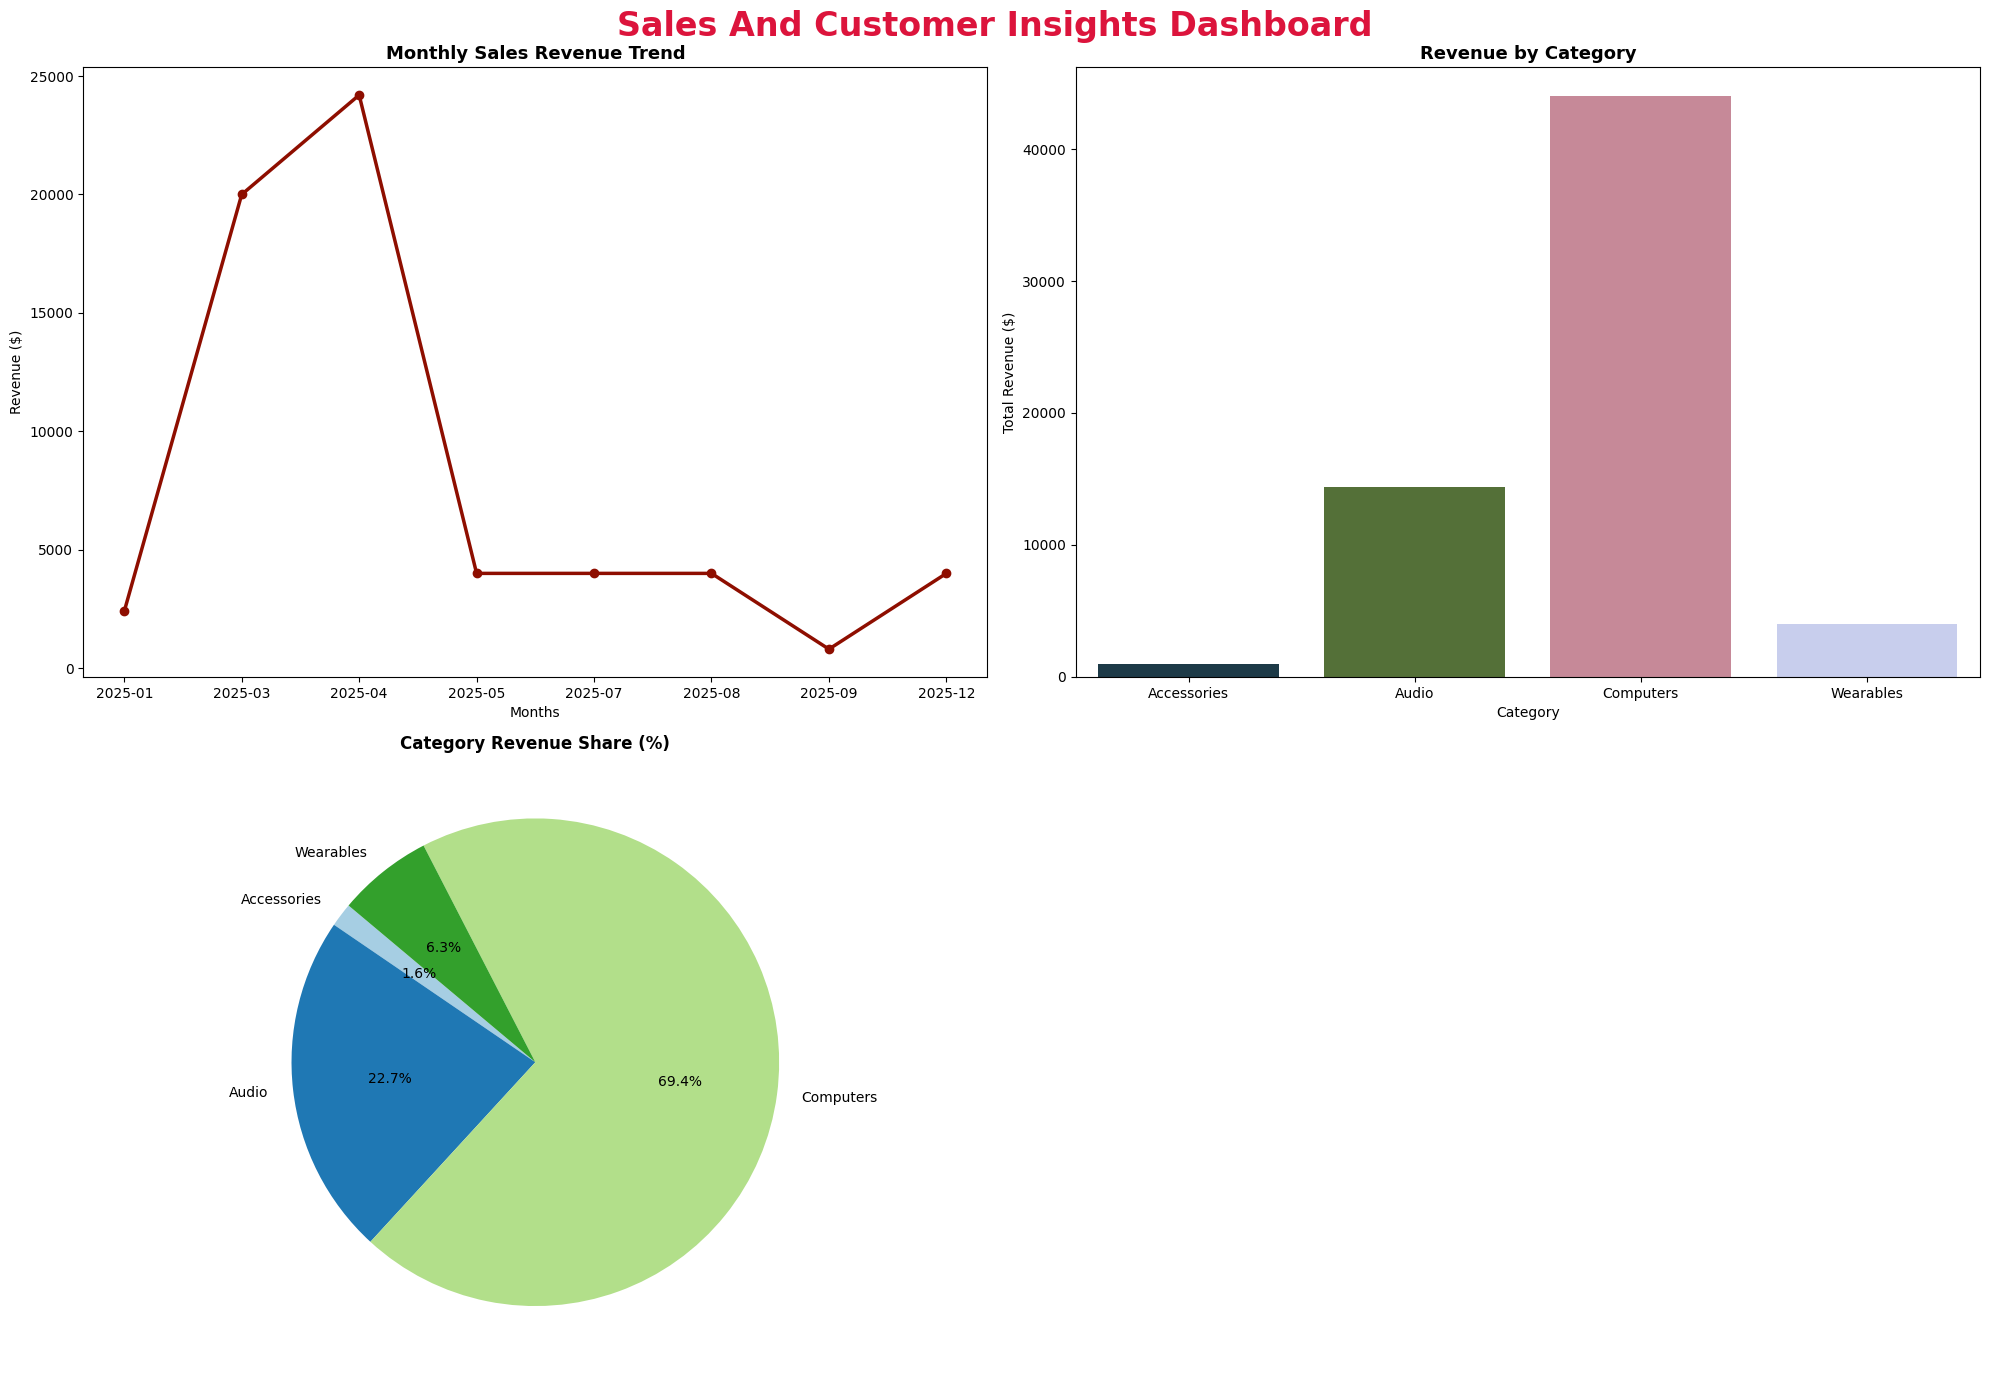

In [24]:
# visualisation
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle("Sales And Customer Insights Dashboard", fontweight='bold', fontsize = 24, color = "crimson")

# Line Plot (Sales Trend)
monthly_sales =df.groupby(df["Date"].dt.to_period('M'))["TotalRevenue"].sum()
monthly_sales.index = monthly_sales.index.astype(str)
axes[0,0].plot(monthly_sales.index,monthly_sales.values, marker ='o'  , color='#8E0E00',linewidth = 2.5)
axes[0,0].set_title("Monthly Sales Revenue Trend", fontsize=13, fontweight="bold")
axes[0,0].set_ylabel("Revenue ($)")
axes[0,0].set_xlabel("Months")

# 2. Use sns.barplot and pass the axis to the `ax` parameter
# (Use axes[1] if 1D array from plt.subplots(1, 3), or axes[0, 1] if 2D grid)
sns.barplot(data=category_sales, x='Category', y='TotalRevenue', palette='cubehelix', ax=axes[0, 1] , hue = 'Category'
)

axes[0, 1].set_title('Revenue by Category', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Total Revenue ($)')

# Pie Chart (Category Distribution Share)
axes[1,0].pie(
    category_sales['TotalRevenue'],
    labels=category_sales['Category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Paired')
)
axes[1,0].set_title('Category Revenue Share (%)', fontsize=12, fontweight='bold')



#removing the last subplot (bottom right) for a cleaner look
fig.delaxes(axes[1, 1])

plt.tight_layout()
plt.show()